# LabPractice 4.1: Stochastic Processes

In [1]:
### Load libraries ###
# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()

# Data management libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Machine Learning libraries
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

---
## 1. Read the dataset

In [2]:
# Import data
df = pd.read_csv('ARIMA_series_mix.csv',sep=";")
df.head()

,y1,y2,y3,y4,y5,y6
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.153085,-0.716578,-1.714427,0.000000,1.672241,-0.491550
2,-0.407418,-0.388769,0.065251,1.450110,1.415559,1.108804
3,0.038315,0.393303,0.508671,3.295469,1.316080,0.584133
4,-0.055686,-1.399870,-0.237498,7.460281,0.225636,0.903927


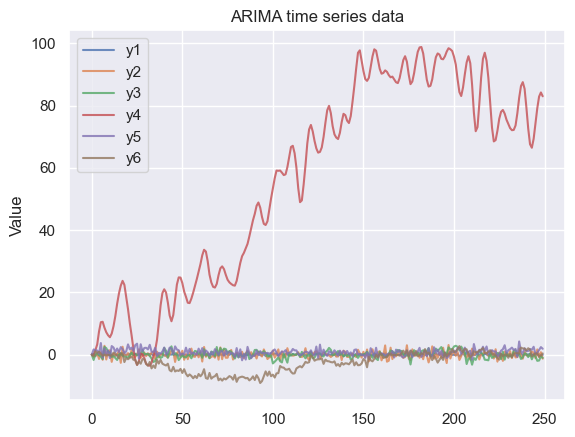

In [6]:

#Hay 4 series que parecen estacionarias
# Plotting a time series
fig, ax = plt.subplots()
for col in df.columns.values.tolist():
    ax.plot(col, data=df, label=col, alpha=0.8)
ax.set(title='ARIMA time series data', ylabel='Value')
plt.legend()
plt.show()


In [8]:
df_ts = df[['y3']] # Maintain data.frame format for column
df_ts

,y3
0,0.000000
1,-1.714427
2,0.065251
3,0.508671
4,-0.237498
...,...
245,-0.558332
246,-1.987523
247,-1.885436
248,-0.579280


<Axes: >

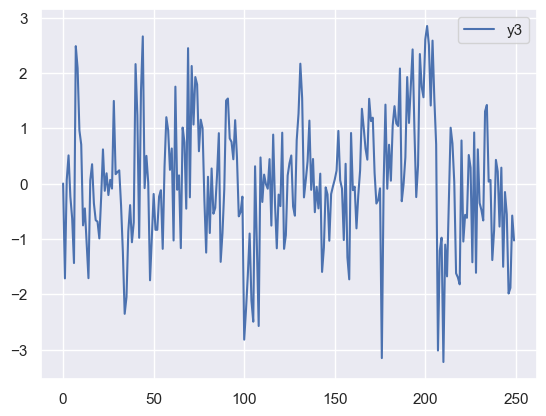

In [10]:
# Plotting a time series
sns.lineplot(data=df_ts)
#Parece estacionaria

---
### Identification process

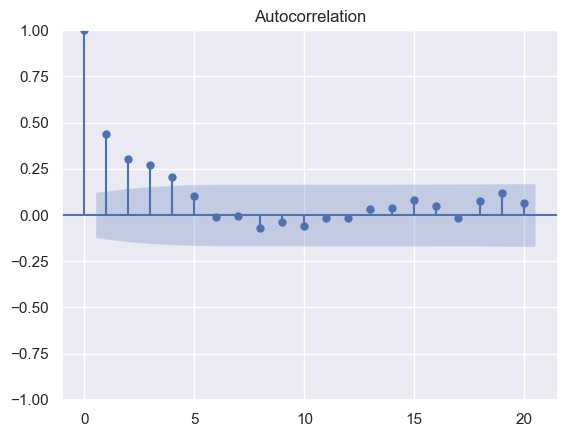

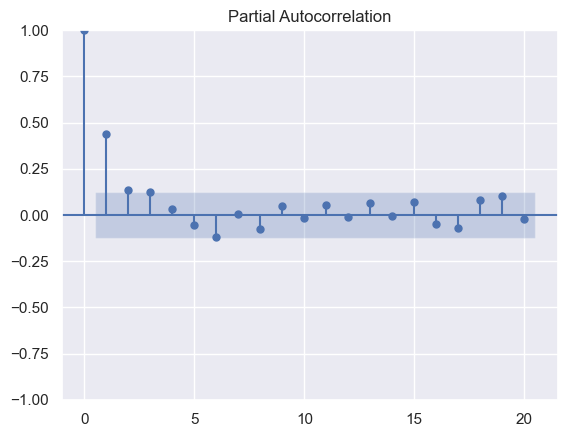

In [12]:
# plot the autocorrelation function
plot_acf(df_ts, lags=20);
# plot the autocorrelation function
plot_pacf(df_ts, lags=20);

#El primero es retardo 0, por eso siempre vale 1.
# Parece un autoregresivo de orden 1 (en PACF solo tenemos uno significativo). (El primero no hay que tenerlo en cuenta porque es el retardo 0).


### Verify if differentiation is needed

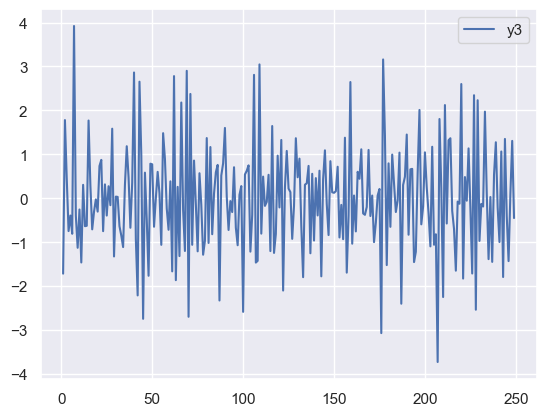

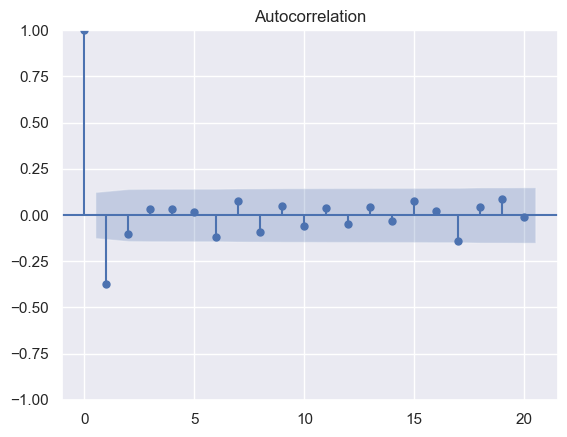

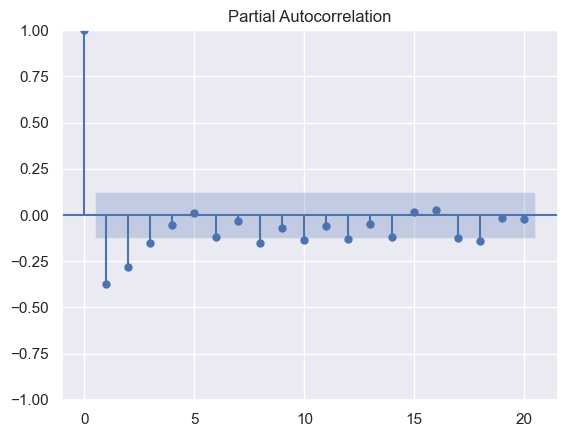

In [14]:
# Difference the data
df_diff = df_ts.diff().dropna()

# Plotting a time series
sns.lineplot(data=df_diff)
# plot the autocorrelation function
plot_acf(df_diff, lags=20);
# plot the autocorrelation function
plot_pacf(df_diff, lags=20);

---
### ARMA model

In [29]:
# Fit model with estimated order
#order=(p,d,q) where:
# p is the number of autoregressive terms,
# d is the differencing order,
# q is the number of moving-average terms.
# trend="n" means no trend | "c" means constant | "t" means linear trend | "ct" means constant and linear trend
arima_fit = ARIMA(df_ts, order=(1,0,0), trend="n").fit() 
print(arima_fit.summary())
#ar.L1=0.44 --> y_t=\phi*y_{t-1} con \phi=0.44

                               SARIMAX Results                                
Dep. Variable:                     y3   No. Observations:                  250
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -364.251
Date:                Mon, 21 Oct 2024   AIC                            732.502
Time:                        18:44:29   BIC                            739.545
Sample:                             0   HQIC                           735.336
                                - 250                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4405      0.057      7.735      0.000       0.329       0.552
sigma2         1.0782      0.089     12.163      0.000       0.904       1.252
Ljung-Box (L1) (Q):                   0.84   Jarque-

#### Analyze model

<Axes: >

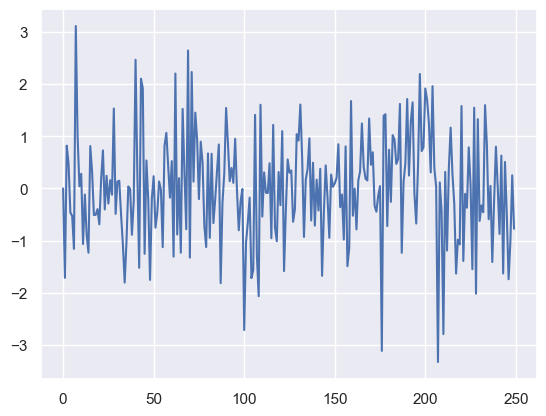

In [32]:
# obtain the residuals
residuals = arima_fit.resid

# plot the residuals
sns.lineplot(data=residuals)

#Lo que tiene que suceder es que nuestro residuos sean ruido blanco. Para comprobar que esto es así, sacamos ACF Y PACF
#EL residuo es la diferencia derivada de intentar explicar nuestra serie a partir de un modelo R1.

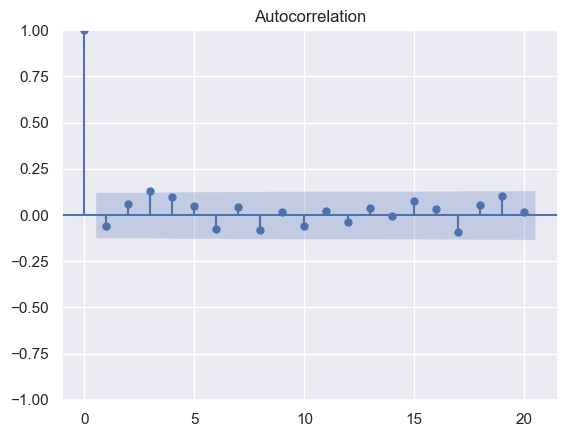

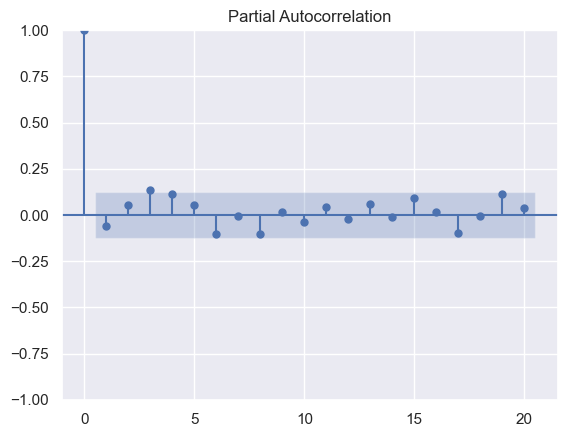

In [34]:
# plot autocorrelation of residuals
plot_acf(residuals, lags=20);
plot_pacf(residuals, lags=20);
# Si pusieramos (0,0,1), el ruido que obtendremos no va a ser ruidao blanco, lo que nos indica que no es el modelo correcto

In [36]:
# ljung-box test
from statsmodels.stats.diagnostic import acorr_ljungbox

# perform the Ljung-Box test
lb_test = acorr_ljungbox(residuals, lags=[20])
lb_test


,lb_stat,lb_pvalue
20,22.515491,0.313206


# Simulate time series

<Axes: ylabel='y3'>

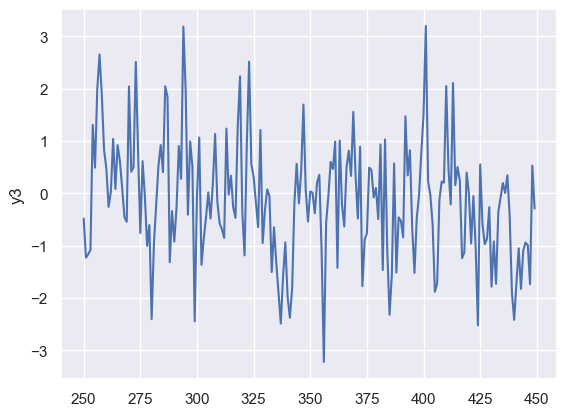

In [40]:
# Podemos simular nuevos datos siguiendo el proceso que hemos simulado

# simulate time series data according to the ARIMA model for future periods
#¿Qué es anchor?
#Tenemos que comprobar que los coeficientes sean siginificativos. (Analizar un modelo de orden (3,0,0)). Nos va auqedar ruido blanco, pero
#el resto de coeficientes superiores a orden 1 no nos van a quedar significativos.
arima_sim = arima_fit.simulate(nsimulations=200, anchor='end')
arima_sim

# plot the simulated data
sns.lineplot(data=arima_sim)

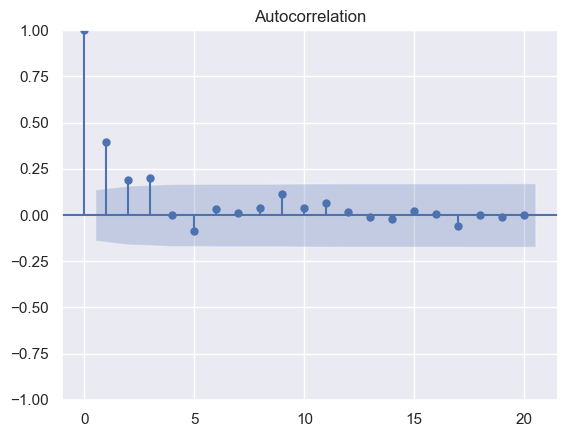

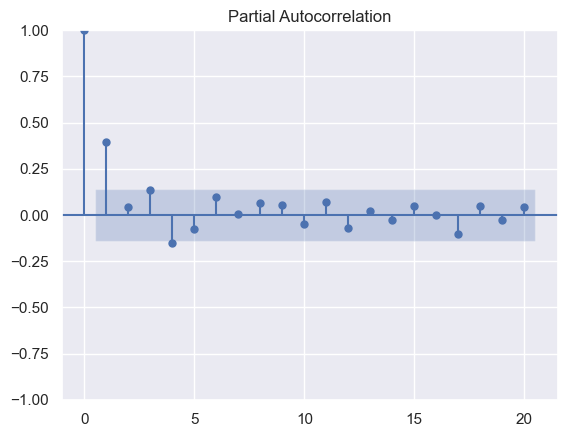

In [42]:
# plot autocorrelation of simulated data
plot_acf(arima_sim, lags=20);
plot_pacf(arima_sim, lags=20);

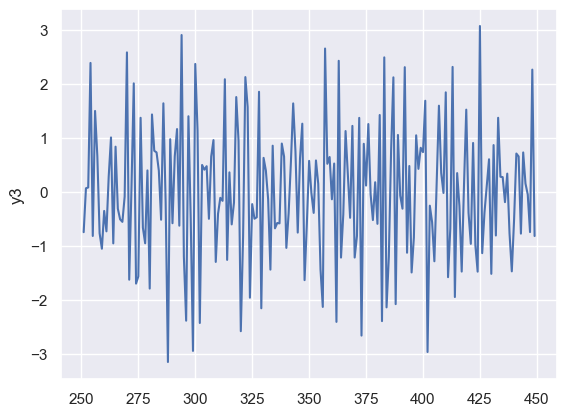

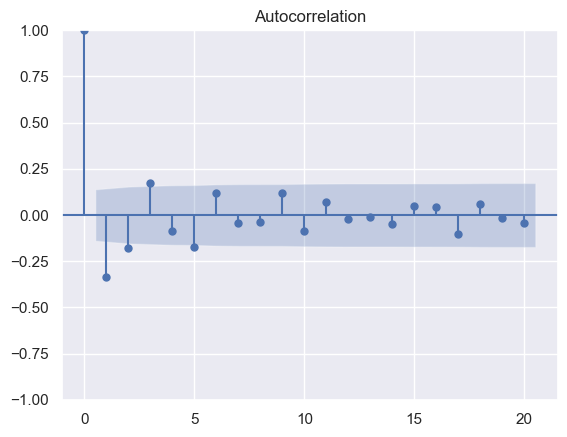

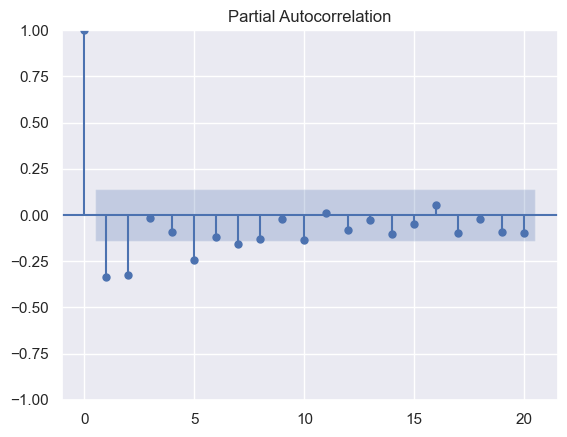

In [44]:
# Difference the simulated data
arima_sim_diff = arima_sim.diff().dropna()

# Plotting a time series
sns.lineplot(data=arima_sim_diff)
# plot the autocorrelation function
plot_acf(arima_sim_diff, lags=20);
# plot the autocorrelation function
plot_pacf(arima_sim_diff, lags=20);